Results saved to serial_recall_Marcus20.csv


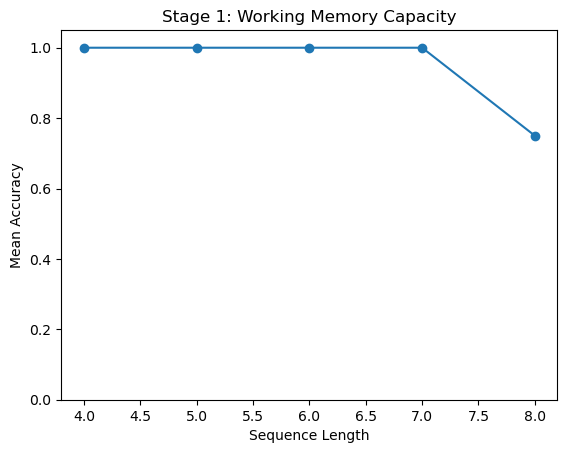



STAGE 2: LETTER CONFUSIONS
No substitution errors were recorded.


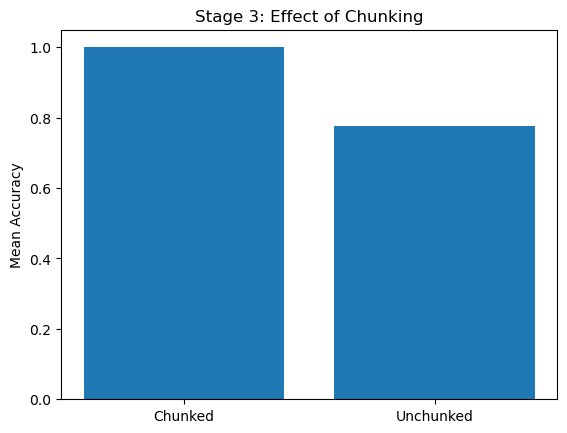

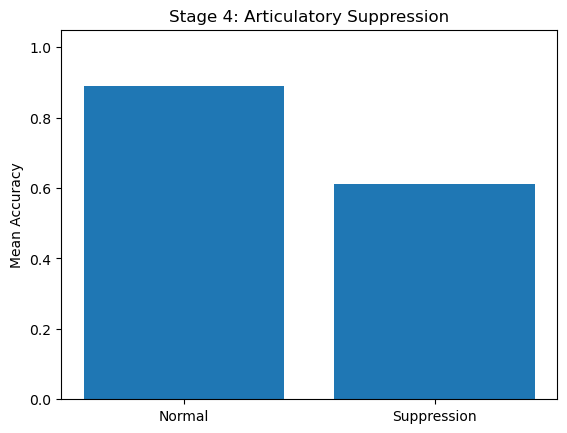

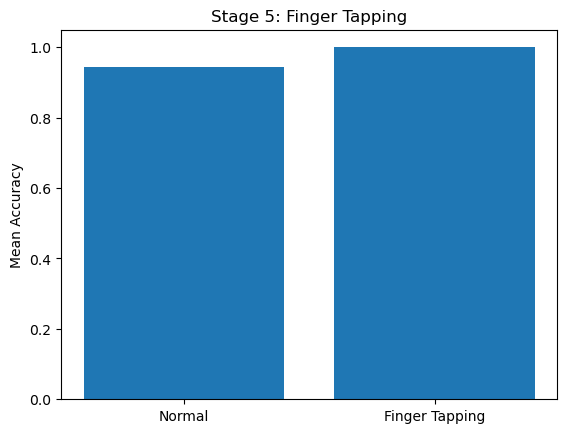

In [44]:
import tkinter as tk
from tkinter import simpledialog, messagebox
import random
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import os


# ============================================================
# EXPERIMENT SETTINGS
# ============================================================

LETTER_TIME = 1000       # milliseconds each letter appears
BLANK_TIME = 250         # blank interval between letters
FIXATION_TIME = 500

LETTERS = list("BCDFGHJKLMNPQRSTVWXYZ")

results = []


# ============================================================
# MAIN EXPERIMENT CLASS
# ============================================================

class SerialRecallExperiment:

    def __init__(self, root):

        self.root = root
        self.root.title("Serial Recall Experiment")
        self.root.geometry("900x600")

        self.label = tk.Label(
            root,
            text="Serial Recall Experiment",
            font=("Arial", 32)
        )

        self.label.pack(expand=True)

        self.participant_id = simpledialog.askstring(
            "Participant ID",
            "Enter participant ID:"
        )

        if not self.participant_id:
            self.participant_id = "Unknown"

        self.run_number = self.get_next_run_number()

        self.start_button = tk.Button(
            root,
            text="Start Experiment",
            font=("Arial", 20),
            command=self.stage1_capacity
        )

        self.start_button.pack(pady=40)


    # ========================================================
    # GET NEXT RUN NUMBER
    # ========================================================

    def get_next_run_number(self):

        filename = (
            f"serial_recall_"
            f"{self.participant_id}.csv"
        )

        if not os.path.exists(filename):
            return 1

        try:

            with open(
                filename,
                "r",
                newline="",
                encoding="utf-8"
            ) as file:

                reader = csv.DictReader(file)

                run_numbers = []

                for row in reader:

                    if row.get("run_number"):

                        try:
                            run_numbers.append(
                                int(row["run_number"])
                            )

                        except ValueError:
                            pass

                if run_numbers:
                    return max(run_numbers) + 1

        except Exception:
            pass

        return 1


        self.start_button = tk.Button(
            root,
            text="Start Experiment",
            font=("Arial", 20),
            command=self.stage1_capacity
        )

        self.start_button.pack(pady=40)


    # ========================================================
    # STAGE 1
    # LIMITED WORKING MEMORY CAPACITY
    # ========================================================

    def stage1_capacity(self):

        self.start_button.destroy()

        messagebox.showinfo(
            "Stage 1",
            "STAGE 1: WORKING MEMORY CAPACITY\n\n"
            "You will see letters one at a time.\n\n"
            "Remember the letters in the exact order.\n"
            "Afterwards, type the sequence you remember."
        )

        trials = []

        sequence_lengths = range(4, 9)

        trials_per_length = 1

        for length in sequence_lengths:

            for repeat in range(trials_per_length):

                sequence = "".join(
                    random.sample(LETTERS, length)
                )

                trials.append({
                    "stage": 1,
                    "experiment": "Capacity",
                    "condition": "Normal",
                    "sequence": sequence
                })

        # Randomise trials
        random.shuffle(trials)

        self.run_trial_list(
            trials,
            callback=self.stage2_errors
        )


    # ========================================================
    # STAGE 2
    # PHONOLOGICAL SIMILARITY
    # ========================================================
    
    def stage2_errors(self):
    
        messagebox.showinfo(
            "Stage 2",
            "STAGE 2: PHONOLOGICAL SIMILARITY\n\n"
            "You will see sequences of 7 letters.\n"
            "Remember them in the exact order."
        )
    
        trials = []
    
        sequence_length = 6
        trials_per_condition = 3
    
        similar_letters = list("BCDEGPTV")
    
        sound_groups = [
            list("AHJK"),
            list("BCDEGPTV"),
            list("FLMNSX"),
            list("IY"),
            list("QUW"),
            list("OR")
        ]
    
        # --------------------------
        # Similar-sounding trials
        # --------------------------
    
        for _ in range(trials_per_condition):
    
            sequence = "".join(
                random.sample(
                    similar_letters,
                    sequence_length
                )
            )
    
            trials.append({
                "stage": 2,
                "experiment": "PhonologicalSimilarity",
                "condition": "SimilarSounding",
                "sequence": sequence
            })
    
        # --------------------------
        # Dissimilar-sounding trials
        # --------------------------
    
        for _ in range(trials_per_condition):
    
            sequence_letters = []
    
            # Pick letters from different sound groups
            groups_shuffled = sound_groups.copy()
            random.shuffle(groups_shuffled)
    
            # Take one from each group first
            for group in groups_shuffled:
    
                if len(sequence_letters) >= sequence_length:
                    break
    
                letter = random.choice(group)
    
                if letter not in sequence_letters:
                    sequence_letters.append(letter)
    
            # Fill any remaining slots
            all_letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    
            while len(sequence_letters) < sequence_length:
    
                letter = random.choice(all_letters)
    
                if letter not in sequence_letters:
                    sequence_letters.append(letter)
    
            random.shuffle(sequence_letters)
    
            sequence = "".join(sequence_letters)
    
            trials.append({
                "stage": 2,
                "experiment": "PhonologicalSimilarity",
                "condition": "DissimilarSounding",
                "sequence": sequence
            })
    
        # Randomise all Stage 2 trials
        random.shuffle(trials)
    
        self.run_trial_list(
            trials,
            callback=self.stage3_chunking
        )
        

    # ========================================================
    # STAGE 3
    # CHUNKING
    # ========================================================
    
    def stage3_chunking(self):
    
        messagebox.showinfo(
            "Stage 3",
            "STAGE 3: CHUNKING\n\n"
            "You will see sequences of letters one at a time.\n\n"
            "Remember the letters in the exact order.\n\n"
            "Some sequences may form familiar words."
        )
    
        trials = []
    
        trials_per_condition = 1
    
        # ----------------------------------------------------
        # WORD BANK
        # ----------------------------------------------------
        # All words are exactly 3 letters long.
        # This means every chunked sequence is:
        #
        # 3 words × 3 letters = 9 letters
        #
        # Example:
        # CAT + DOG + SUN = CATDOGSUN
        # ----------------------------------------------------
    
        word_bank = [
            "CAT", "DOG", "SUN", "CAR", "BUS",
            "MAP", "RED", "PEN", "BOX", "HAT",
            "CUP", "BED", "PIG", "COW", "HEN",
            "BAT", "FOX", "ANT", "BEE", "OWL",
            "RUN", "SIT", "EAT", "TEA", "EGG",
            "SEA", "SKY", "ICE", "KEY", "BAG",
            "TOP", "TOY", "LEG", "ARM", "EAR",
            "EYE", "LIP", "MAN", "BOY", "GIR",
            "NET", "LOG", "PAN", "POT", "JAR",
            "CAP", "FAN", "MAT", "RUG", "VAN"
        ]
    
        # Remove anything that is accidentally not 3 letters
        word_bank = [
            word
            for word in word_bank
            if len(word) == 3
        ]
    
    
        # ====================================================
        # CHUNKED CONDITION
        # ====================================================
    
        used_chunked = set()
    
        while len(used_chunked) < trials_per_condition:
    
            # Select 3 different words
            words = random.sample(
                word_bank,
                3
            )
    
            sequence = "".join(words)
    
            if sequence not in used_chunked:
    
                used_chunked.add(sequence)
    
                trials.append({
                    "stage": 3,
                    "experiment": "Chunking",
                    "condition": "Chunked",
                    "sequence": sequence
                })
    
    
        # ====================================================
        # UNCHUNKED CONDITION
        # ====================================================
        #
        # Generate random 9-letter strings.
        #
        # Use consonants so they are less likely to
        # accidentally form familiar words.
        # ====================================================
    
        consonants = list(
            "BCDFGHJKLMNPQRSTVWXYZ"
        )
    
        used_unchunked = set()
    
        while len(used_unchunked) < trials_per_condition:
    
            sequence = "".join(
                random.sample(
                    consonants,
                    9
                )
            )
    
            if sequence not in used_unchunked:
    
                used_unchunked.add(sequence)
    
                trials.append({
                    "stage": 3,
                    "experiment": "Chunking",
                    "condition": "Unchunked",
                    "sequence": sequence
                })
    
    
        # ----------------------------------------------------
        # RANDOMISE CONDITION ORDER
        # ----------------------------------------------------
    
        random.shuffle(trials)
    
    
        # ----------------------------------------------------
        # RUN STAGE 3
        # ----------------------------------------------------
    
        self.run_trial_list(
            trials,
            callback=self.stage4_suppression
        )

    # ========================================================
    # STAGE 4
    # ARTICULATORY SUPPRESSION
    # ========================================================

    def stage4_suppression(self):

        messagebox.showinfo(
            "Stage 4",
            "STAGE 4: ARTICULATORY SUPPRESSION\n\n"
            "There will be TWO conditions:\n\n"
            "1. Normal recall\n"
            "2. Repeatedly saying 'TA-DA, TA-DA...'\n\n"
            "Follow the instruction shown before each block."
        )

        self.stage4_conditions = [
            "Normal",
            "Suppression"
        ]

        random.shuffle(self.stage4_conditions)

        self.stage4_condition_index = 0

        self.run_stage4_block()


    def run_stage4_block(self):

        if self.stage4_condition_index >= len(
            self.stage4_conditions
        ):

            self.stage5_finger_tapping()
            return

        condition = self.stage4_conditions[
            self.stage4_condition_index
        ]

        if condition == "Normal":

            instructions = (
                "NORMAL CONDITION\n\n"
                "Remember the letters normally."
            )

        else:

            instructions = (
                "SUPPRESSION CONDITION\n\n"
                "Continuously say:\n\n"
                "TA-DA, TA-DA, TA-DA...\n\n"
                "while the letters are being shown.\n\n"
                "Stop after the final letter disappears."
            )

        messagebox.showinfo(
            "Stage 4",
            instructions
        )

        trials = []

        for repeat in range(3):

            sequence = "".join(
                random.sample(
                    LETTERS,
                    6
                )
            )

            trials.append({
                "stage": 4,
                "experiment": "ArticulatorySuppression",
                "condition": condition,
                "sequence": sequence
            })

        self.run_trial_list(
            trials,
            callback=self.next_stage4_condition
        )


    def next_stage4_condition(self):

        self.stage4_condition_index += 1

        self.run_stage4_block()


    # ========================================================
    # STAGE 5
    # FINGER TAPPING
    # ========================================================

    def stage5_finger_tapping(self):

        messagebox.showinfo(
            "Stage 5",
            "STAGE 5: FINGER TAPPING\n\n"
            "There will be TWO conditions:\n\n"
            "1. Normal recall\n"
            "2. Finger tapping while remembering\n\n"
            "Follow the instruction shown before each block."
        )

        self.stage5_conditions = [
            "Normal",
            "FingerTapping"
        ]

        random.shuffle(self.stage5_conditions)

        self.stage5_condition_index = 0

        self.run_stage5_block()


    def run_stage5_block(self):

        if self.stage5_condition_index >= len(
            self.stage5_conditions
        ):

            self.finish_experiment()
            return

        condition = self.stage5_conditions[
            self.stage5_condition_index
        ]

        if condition == "Normal":

            instructions = (
                "NORMAL CONDITION\n\n"
                "Remember the letters normally."
            )

        else:

            instructions = (
                "FINGER TAPPING CONDITION\n\n"
                "Continuously tap one finger on the desk\n"
                "while the letters are being shown.\n\n"
                "Stop tapping after the final letter disappears."
            )

        messagebox.showinfo(
            "Stage 5",
            instructions
        )

        trials = []

        for repeat in range(3):

            sequence = "".join(
                random.sample(
                    LETTERS,
                    6
                )
            )

            trials.append({
                "stage": 5,
                "experiment": "FingerTapping",
                "condition": condition,
                "sequence": sequence
            })

        self.run_trial_list(
            trials,
            callback=self.next_stage5_condition
        )


    def next_stage5_condition(self):

        self.stage5_condition_index += 1

        self.run_stage5_block()


    # ========================================================
    # GENERAL TRIAL SYSTEM
    # ========================================================

    def run_trial_list(self, trials, callback):

        self.current_trials = trials
        self.current_trial_index = 0
        self.after_trials_callback = callback

        self.run_next_trial()


    def run_next_trial(self):

        if self.current_trial_index >= len(
            self.current_trials
        ):

            self.after_trials_callback()
            return

        self.current_trial = self.current_trials[
            self.current_trial_index
        ]

        self.show_fixation()


    # ========================================================
    # SHOW FIXATION
    # ========================================================

    def show_fixation(self):

        self.label.config(
            text="+",
            font=("Arial", 45)
        )

        self.root.after(
            FIXATION_TIME,
            lambda: self.show_letter(0)
        )


    # ========================================================
    # SHOW LETTERS
    # ========================================================

    def show_letter(self, index):

        sequence = self.current_trial["sequence"]

        if index >= len(sequence):

            self.label.config(text="")

            self.root.after(
                BLANK_TIME,
                self.collect_response
            )

            return

        self.label.config(
            text=sequence[index],
            font=("Arial", 72)
        )

        self.root.after(
            LETTER_TIME,
            lambda: self.blank_screen(index)
        )


    def blank_screen(self, index):

        self.label.config(text="")

        self.root.after(
            BLANK_TIME,
            lambda: self.show_letter(index + 1)
        )


    # ========================================================
    # COLLECT PARTICIPANT RESPONSE
    # ========================================================

    def collect_response(self):

        response = simpledialog.askstring(
            "Recall",
            "Enter the letters in the exact order:"
        )

        if response is None:
            response = ""

        response = (
            response.upper()
            .replace(" ", "")
        )

        target = self.current_trial["sequence"]

        correct_positions = 0

        for i in range(
            min(
                len(target),
                len(response)
            )
        ):

            if target[i] == response[i]:

                correct_positions += 1

        accuracy = (
            correct_positions /
            len(target)
        )

        results.append({

            "participant":
                self.participant_id,
            "run_number": 
                self.run_number,
            "stage":
                self.current_trial["stage"],

            "experiment":
                self.current_trial["experiment"],

            "condition":
                self.current_trial["condition"],

            "sequence_length":
                len(target),

            "target":
                target,

            "response":
                response,

            "correct_positions":
                correct_positions,

            "accuracy":
                accuracy

        })

        self.current_trial_index += 1

        self.root.after(
            300,
            self.run_next_trial
        )


    # ========================================================
    # FINISH EXPERIMENT
    # ========================================================

    def finish_experiment(self):

        self.save_results()

        self.label.config(
            text="Experiment Complete!",
            font=("Arial", 32)
        )

        messagebox.showinfo(
            "Finished",
            "All five stages are complete.\n\n"
            "The results have been saved."
        )

        self.analyse_results()


    # ========================================================
    # SAVE DATA
    # ========================================================

    def save_results(self):
    
        filename = (
            f"serial_recall_"
            f"{self.participant_id}.csv"
        )
    
        fields = [
            "participant",
            "run_number",
            "stage",
            "experiment",
            "condition",
            "sequence_length",
            "target",
            "response",
            "correct_positions",
            "accuracy"
        ]
    
        file_exists = os.path.exists(filename)
    
        with open(
            filename,
            "a",
            newline="",
            encoding="utf-8"
        ) as file:
    
            writer = csv.DictWriter(
                file,
                fieldnames=fields
            )
    
            if not file_exists:
                writer.writeheader()
    
            writer.writerows(
                results
            )
    
        print(
            f"Results saved to {filename}"
        )

    # ========================================================
    # RESULT ANALYSIS
    # ========================================================

    def analyse_results(self):

        self.analyse_stage1()

        self.analyse_stage2()

        self.analyse_stage3()

        self.analyse_stage4()

        self.analyse_stage5()


    # ========================================================
    # ANALYSIS: STAGE 1
    # ========================================================

    def analyse_stage1(self):

        data = defaultdict(list)

        for row in results:

            if row["stage"] == 1:

                data[
                    row["sequence_length"]
                ].append(
                    row["accuracy"]
                )

        lengths = sorted(
            data.keys()
        )

        averages = []

        for length in lengths:

            averages.append(
                sum(data[length]) /
                len(data[length])
            )

        plt.figure()

        plt.plot(
            lengths,
            averages,
            marker="o"
        )

        plt.xlabel(
            "Sequence Length"
        )

        plt.ylabel(
            "Mean Accuracy"
        )

        plt.title(
            "Stage 1: Working Memory Capacity"
        )

        plt.ylim(
            0,
            1.05
        )

        plt.show()


    # ========================================================
    # ANALYSIS: STAGE 2
    # ========================================================

    def analyse_stage2(self):

        confusions = defaultdict(int)

        for row in results:

            if row["stage"] != 2:
                continue

            target = row["target"]
            response = row["response"]

            minimum_length = min(
                len(target),
                len(response)
            )

            for i in range(
                minimum_length
            ):

                if target[i] != response[i]:

                    confusion = (
                        target[i],
                        response[i]
                    )

                    confusions[
                        confusion
                    ] += 1

        print("\n")
        print("=" * 50)
        print("STAGE 2: LETTER CONFUSIONS")
        print("=" * 50)

        if not confusions:

            print(
                "No substitution errors were recorded."
            )

        else:

            sorted_errors = sorted(
                confusions.items(),
                key=lambda x: x[1],
                reverse=True
            )

            for (
                correct_letter,
                recalled_letter
            ), count in sorted_errors:

                print(
                    f"{correct_letter} "
                    f"-> "
                    f"{recalled_letter}: "
                    f"{count}"
                )


    # ========================================================
    # ANALYSIS: STAGE 3
    # ========================================================

    def analyse_stage3(self):

        chunked = []
        unchunked = []

        for row in results:

            if row["stage"] == 3:

                if (
                    row["condition"]
                    == "Chunked"
                ):

                    chunked.append(
                        row["accuracy"]
                    )

                else:

                    unchunked.append(
                        row["accuracy"]
                    )

        means = [

            sum(chunked) /
            len(chunked),

            sum(unchunked) /
            len(unchunked)

        ]

        plt.figure()

        plt.bar(
            [
                "Chunked",
                "Unchunked"
            ],
            means
        )

        plt.ylabel(
            "Mean Accuracy"
        )

        plt.title(
            "Stage 3: Effect of Chunking"
        )

        plt.ylim(
            0,
            1.05
        )

        plt.show()


    # ========================================================
    # ANALYSIS: STAGE 4
    # ========================================================

    def analyse_stage4(self):

        normal = []
        suppression = []

        for row in results:

            if row["stage"] == 4:

                if (
                    row["condition"]
                    == "Normal"
                ):

                    normal.append(
                        row["accuracy"]
                    )

                else:

                    suppression.append(
                        row["accuracy"]
                    )

        means = [

            sum(normal) /
            len(normal),

            sum(suppression) /
            len(suppression)

        ]

        plt.figure()

        plt.bar(
            [
                "Normal",
                "Suppression"
            ],
            means
        )

        plt.ylabel(
            "Mean Accuracy"
        )

        plt.title(
            "Stage 4: Articulatory Suppression"
        )

        plt.ylim(
            0,
            1.05
        )

        plt.show()


    # ========================================================
    # ANALYSIS: STAGE 5
    # ========================================================

    def analyse_stage5(self):

        normal = []
        tapping = []

        for row in results:

            if row["stage"] == 5:

                if (
                    row["condition"]
                    == "Normal"
                ):

                    normal.append(
                        row["accuracy"]
                    )

                else:

                    tapping.append(
                        row["accuracy"]
                    )

        means = [

            sum(normal) /
            len(normal),

            sum(tapping) /
            len(tapping)

        ]

        plt.figure()

        plt.bar(
            [
                "Normal",
                "Finger Tapping"
            ],
            means
        )

        plt.ylabel(
            "Mean Accuracy"
        )

        plt.title(
            "Stage 5: Finger Tapping"
        )

        plt.ylim(
            0,
            1.05
        )

        plt.show()


# ============================================================
# RUN PROGRAM
# ============================================================

root = tk.Tk()

experiment = SerialRecallExperiment(
    root
)

root.mainloop()

In [3]:
import os
print(os.getcwd())

C:\Users\yuenm


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel(
    "serial_recall_cleaned.xlsx",
    sheet_name="Cleaned Data"
)

# We deliberately ignore participant and run_number.
# All trials are treated as part of the same dataset.

print(df.head())
print("Number of trials:", len(df))

  participant  stage experiment condition  sequence_length    target response  \
0     Marcus1      1   Capacity    Normal                5     YFKXQ    YFKXQ   
1     Marcus1      1   Capacity    Normal                4      VQCF     VQCF   
2     Marcus1      1   Capacity    Normal                6    SDMNCP   SDMNCP   
3     Marcus1      1   Capacity    Normal                7   SYMVNKX   SYMVKX   
4     Marcus1      1   Capacity    Normal                8  QNXCLHKT  QNXCHKT   

   correct_positions  accuracy  
0                  5  1.000000  
1                  4  1.000000  
2                  6  1.000000  
3                  4  0.571429  
4                  4  0.500000  
Number of trials: 1000


In [52]:
# ============================================================
# PREPARE DATA FOR ONE CONSOLIDATED FIGURE
# ============================================================

plot_data = []

# ------------------------------------------------------------
# STAGE 1: Working memory capacity
# ------------------------------------------------------------

stage1 = df[df["stage"] == 1]

for length in sorted(stage1["sequence_length"].unique()):

    values = stage1[
        stage1["sequence_length"] == length
    ]["accuracy"]

    plot_data.append({
        "label": f"{int(length)} letters",
        "stage": "Stage 1\nCapacity",
        "mean": values.mean(),
        "sem": values.sem()
    })


# ------------------------------------------------------------
# STAGE 2: Phonological similarity
# ------------------------------------------------------------

stage2 = df[df["stage"] == 2]

for condition in stage2["condition"].unique():

    values = stage2[
        stage2["condition"] == condition
    ]["accuracy"]

    label = {
        "SimilarSounding": "Similar\nsounding",
        "DissimilarSounding": "Dissimilar\nsounding",
        "SimilarLooking": "Similar\nlooking"
    }.get(condition, condition)

    plot_data.append({
        "label": label,
        "stage": "Stage 2\nSimilarity",
        "mean": values.mean(),
        "sem": values.sem()
    })


# ------------------------------------------------------------
# STAGE 3: Chunking
# ------------------------------------------------------------

stage3 = df[df["stage"] == 3]

for condition in ["Chunked", "Unchunked"]:

    values = stage3[
        stage3["condition"] == condition
    ]["accuracy"]

    if len(values) > 0:

        plot_data.append({
            "label": condition,
            "stage": "Stage 3\nChunking",
            "mean": values.mean(),
            "sem": values.sem()
        })


# ------------------------------------------------------------
# STAGE 4: Articulatory suppression
# ------------------------------------------------------------

stage4 = df[df["stage"] == 4]

for condition in ["Normal", "Suppression"]:

    values = stage4[
        stage4["condition"] == condition
    ]["accuracy"]

    if len(values) > 0:

        plot_data.append({
            "label": condition,
            "stage": "Stage 4\nArticulatory\nsuppression",
            "mean": values.mean(),
            "sem": values.sem()
        })


# ------------------------------------------------------------
# STAGE 5: Finger tapping
# ------------------------------------------------------------

stage5 = df[df["stage"] == 5]

for condition in ["Normal", "FingerTapping"]:

    values = stage5[
        stage5["condition"] == condition
    ]["accuracy"]

    if len(values) > 0:

        label = (
            "Finger\ntapping"
            if condition == "FingerTapping"
            else "Normal"
        )

        plot_data.append({
            "label": label,
            "stage": "Stage 5\nFinger tapping",
            "mean": values.mean(),
            "sem": values.sem()
        })


plot_df = pd.DataFrame(plot_data)

plot_df

,label,stage,mean,sem
0,4 letters,Stage 1\nCapacity,0.968750,0.025613
1,5 letters,Stage 1\nCapacity,0.915000,0.040438
2,6 letters,Stage 1\nCapacity,0.845833,0.044010
3,7 letters,Stage 1\nCapacity,0.760714,0.041990
4,8 letters,Stage 1\nCapacity,0.546875,0.043090
5,Dissimilar\nsounding,Stage 2\nSimilarity,0.909722,0.022043
6,Similar\nsounding,Stage 2\nSimilarity,0.752778,0.026240
7,Chunked,Stage 3\nChunking,0.961111,0.017135
8,Unchunked,Stage 3\nChunking,0.450000,0.047567
9,Normal,Stage 4\nArticulatory\nsuppression,0.891667,0.021303


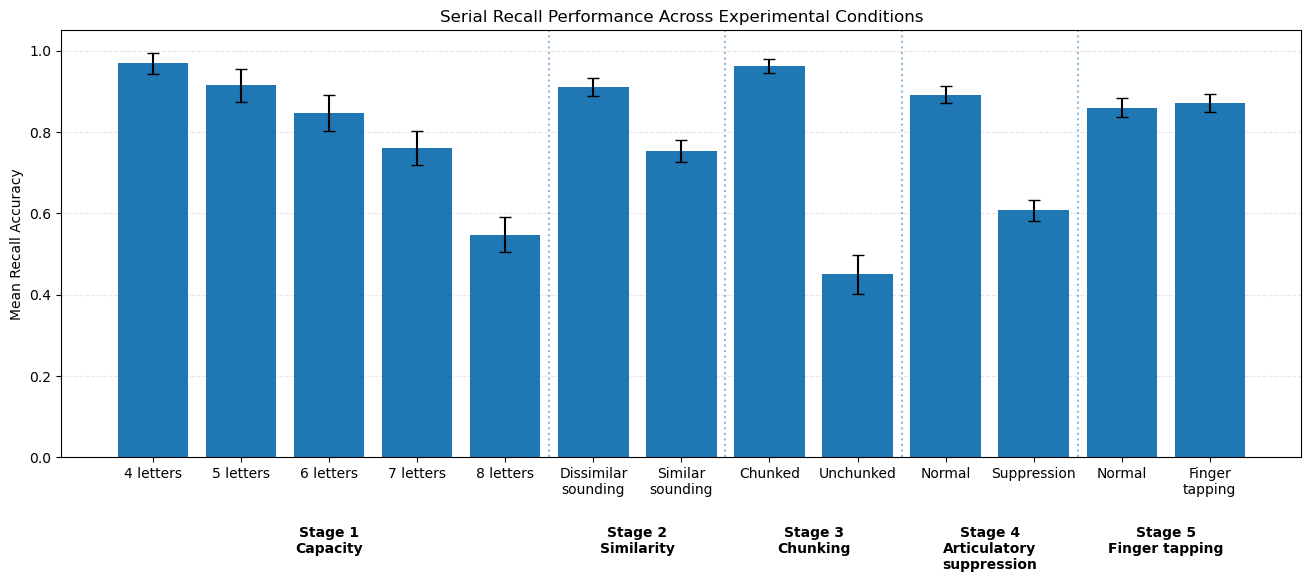

In [54]:
# ============================================================
# CREATE ONE CONSOLIDATED FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(plot_df))

ax.bar(
    x,
    plot_df["mean"],
    yerr=plot_df["sem"],
    capsize=4
)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["label"],
    rotation=0
)

# Y-axis
ax.set_ylabel("Mean Recall Accuracy")
ax.set_ylim(0, 1.05)

# Title
ax.set_title(
    "Serial Recall Performance Across Experimental Conditions"
)

# Horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


# ============================================================
# ADD STAGE SEPARATORS AND LABELS
# ============================================================

stage_groups = plot_df.groupby(
    "stage",
    sort=False
)

boundaries = []
centres = []

start = 0

for stage, group in stage_groups:

    end = start + len(group)

    centre = (start + end - 1) / 2

    centres.append(
        (centre, stage)
    )

    boundaries.append(end - 0.5)

    start = end


# Vertical lines between stages
for boundary in boundaries[:-1]:

    ax.axvline(
        boundary,
        linestyle=":",
        alpha=0.5
    )


# Stage labels underneath condition labels
for centre, stage in centres:

    ax.text(
        centre,
        -0.16,
        stage,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontweight="bold"
    )


plt.subplots_adjust(
    bottom=0.27
)

plt.show()